# Imports

In [2]:
import os
import utils
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import ceinms
import openSim
import pandas as pd

ModuleNotFoundError: No module named 'utils'

# Preprocessing

In [ ]:
import shutil


def copy_input_files(src_session_path, dest_session_path, trial_list):
    """
    Copy necessary input files from source trial to destination trial.
    """
    input_files = [
        'trial_settings.xml',
    ]
    
    for trial in trial_list:
        src_trial_path = os.path.join(src_session_path, trial)
        dest_trial_path = os.path.join(dest_session_path, trial)
        
        os.makedirs(dest_trial_path, exist_ok=True)
        
        for file_name in input_files:
            src_file = os.path.join(src_trial_path, file_name)
            dest_file = os.path.join(dest_trial_path, file_name)
            if os.path.exists(src_file):
                shutil.copy2(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")
            else:
                print(f"Warning: {src_file} does not exist and was not copied.")

src_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31')
dest_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_Katya', '25_03_31')
trials_to_copy = ['Squat_35kg_01', 'Squat_bw_01', 'Walking_02']

copy_input_files(src_session, dest_session, trials_to_copy)

# Single trial analysis

## Initiate trial

In [ ]:
subject = 'Athlete_03_MRI_BG' # 'Athlete_03', 'Athlete_03_MRI_BG'
session = '25_03_31'
trial = 'Squat_35kg_01'  # 'Walking_02', 'Squat_35kg_01', 'Squat_bw_01'

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject, session, trial) # Walking_02, Squat_bw_01, Squat_35kg_01
print(f'Analyzing trial at path: {trialPath}')

analysis = utils.Analyse(trialPath)
# analysis.reset_settings_xml()
# print main inputs
print("Main inputs:")
print(f"Model file: {analysis.model_dir}")
print(f"time range: {analysis.time_range}")

# open settings.xml in the editor
settings_xml_path = os.path.join(trialPath, 'trial_settings.xml')
os.startfile(settings_xml_path)

## reload settings

In [ ]:
# analysis.update_trial_attribute('Target_Muscles', 'all')
analysis.delete_trial_attribute('EMG_muscle_mapping')
analysis.load_settings(analysis.settingsXML)
print(f'{analysis.model_dir}')

## Export C3D

In [ ]:
# analysis.export_c3d()

## Optimise model (modonese)

In [ ]:
import muscleOptimizer

muscleOptimizer.main(osim_model_targ_filepath=analysis.model_dir,
                     osim_model_ref_filepath=os.path.join(utils.MODELS_DIR, 'Catelli-V4.0_PowerliftingMarkers.osim'))

## Increase model isometric force

In [ ]:
analysis.increase_muscle_force(factor=3.0)

## Run IK

In [ ]:
analysis.replace = True
analysis.run_ik()
analysis.plot_ik()


## run id

In [ ]:
analysis.run_id()
analysis.plot_id()

## run ma

In [ ]:
analysis.run_ma()

### plot

In [ ]:
analysis.plot_moment_arms()

## run so

In [ ]:
analysis.replace = True
analysis.run_so()

## run jra

In [ ]:
analysis.replace = True
analysis.run_jra()

## emg normalise / scale / plot

In [ ]:
analysis.run_emg_normalise()
analysis.scale_emg(scale_factor=0.70)
# analysis.plot_emg()

## Create ceinms setup files

In [ ]:
analysis.replace = False

analysis.create_ceinms_model()

analysis.create_ceinms_input_data()

analysis.create_ceinms_calibration_cfg(calibration_trial_names=['Squat_bw_01'])

analysis.create_ceinms_calibration_setup()

analysis.create_excitation_generator()

analysis.create_ceinms_exe_cfg()

analysis.create_ceinms_exe_setup()

## ceinms calibration

In [ ]:

setupXML_path = os.path.join(analysis.path, analysis.ceinms_calibration_setup)

if False: ceinms.calibrate(setupXML_path)
if False: ceinms.plot_ceinms_calibration_results(setupXML_path=setupXML_path)

setupXML = ET.parse(setupXML_path).getroot()

ucalibrated_model_name = setupXML.find('subjectFile').text
uncalibrated_model_path = os.path.relpath(os.path.join(os.path.dirname(setupXML_path), ucalibrated_model_name), analysis.path)

calibrated_model_name = setupXML.find('outputSubjectFile').text
calibrated_model_path = os.path.relpath(os.path.join(os.path.dirname(setupXML_path), calibrated_model_name), analysis.path)


ceinms.plot_ceinms_model_parameters(ceinmsModelPath=calibrated_model_path)

ceinms.plot_compare_ceinms_models(uncalibratedModelPath=uncalibrated_model_path, calibratedModelPath=calibrated_model_path)

In [ ]:
ceinms.plot_compare_ceinms_models(uncalibratedModelPath=os.path.join(analysis.path, '..\subjectUncalibrated.xml'), calibratedModelPath=os.path.join(analysis.path, '..\subjectCalibrated.xml'))

## run ceinms exe

In [ ]:
analysis.run_ceinms_exe()

## ceinms optimise

In [ ]:
analysis.run_ceinms_optimise()

In [ ]:
ceinms.plot_optimisation_results(analysis.ceinms_optimisation_dir)

ceinms_excitations = os.path.join(analysis.ceinms_optimisation_dir, 'AdjustedEmgs.sto')
ceinms_torques = os.path.join(analysis.ceinms_optimisation_dir, 'Torques.sto')

ceinms.plot_experimental_vs_ceinms(emgFile=analysis.emg_normalised, ceinmsExcitationsFile=ceinms_excitations, excitationGeneratorFile=analysis.ceinms_excitation_generator, externalMomentsFile=analysis.id,ceinmsTorquesFile=ceinms_torques)

## JRA ceinms 

In [ ]:
analysis.replace = True
new_model = os.path.join(utils.MODELS_DIR, subject, session, 'scaled.osim')
analysis.update_model(new_model)
analysis.run_jra_ceinms()
analysis.plot_jra(origin='CEINMS')

## JRA 

In [ ]:
new_model = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_increased_3.00.osim')
analysis.update_model(new_model)
analysis.run_jra()
analysis.plot_jra(origin='SO')

## push to git

In [ ]:
analysis.push_trial_results_to_git()

# Troubleshoot

In [ ]:
analysis.load_settings(analysis.settingsXML)
osim_modelPath = analysis.model_dir
ik_output = os.path.join(analysis.path, analysis.ik)
grf_xml = os.path.join(analysis.path, analysis.setup_grf)
setup_jra_xml = os.path.join(analysis.path, analysis.setup_jra)
actuators_xml = None
muscle_force_path = os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('MuscleForces', 'MuscleForces_updated')
saveFileName = os.path.join(analysis.path, "JRA_results.sto")

openSim.run_jra(osim_modelPath=osim_modelPath, 
                ik_output=ik_output, 
                grf_xml=grf_xml, 
                setup_xml=setup_jra_xml, 
                actuators=actuators_xml, 
                muscle_force_path=muscle_force_path, 
                saveFileName=saveFileName)

In [ ]:
setupXML_path = r'C:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\ceinms_setup.xml'
ceinms.executable(setupXML_path)

## Compare multiple files

In [ ]:
filepath1 = os.path.join(analysis.path, analysis.jra)
filepath2 = os.path.join(analysis.path, analysis.jra_ceinms)
filepath3 = os.path.join(analysis.path, analysis.jra_ceinms).replace('MuscleForces', 'MuscleForces_updated')

files = {'so': utils.load_any_data_file(filepath1),
         'ceinms': utils.load_any_data_file(filepath2),
         'ceinms_with_SO_updated': utils.load_any_data_file(filepath3)}

results_dir = os.path.join(utils.RESULTS_DIR, 'compare')
os.makedirs(results_dir, exist_ok=True)

common_columns = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz', 'walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz', 'ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

nrows, ncols = utils.calculate_nRows_nCols(len(common_columns))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6*nrows))

for file_key, data in files.items():
    print(f"{file_key} columns: {data.columns}")

    for idx, column in enumerate(common_columns):
        row = idx // ncols
        col = idx % ncols
        ax[row, col].plot(data['time'], data[column], label=file_key)
        ax[row, col].set_title(column)
        ax[row, col].set_xlabel('Time (s)')
        ax[row, col].set_ylabel('Value')
        ax[row, col].legend()
# plt.tight_layout()
save_path = os.path.join(results_dir, 'comparison_plot.png')

In [ ]:
# compare columns SO vs CEINMS forces
ceinms_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms))
so_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_forces))

for column in so_forces.columns:
    if not column in ceinms_forces.columns:
        print(f"Column {column} not found in CEINMS forces.")
        
        # add column to ceinms_forces with the same valuse as SO
        ceinms_forces[column] = so_forces[column]

utils.write_sto_file(ceinms_forces, os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto'))
print(f"Saved updated CEINMS forces to {os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto')}")
        

# Plots single trials MRI vs Linear scaled

## Initiate settings

In [2]:
import matplotlib.pyplot as plt
import opensim as osim
ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'ankle_angle_r_moment']

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

subject1 = 'Athlete_03'
subject2 = 'Athlete_03_MRI_BG'
session = '25_03_31'
trialName = 'Walking_02' # 'Walking_02', 'Squat_bw_01', 'Squat_35kg_01'

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

results_dir = os.path.join(utils.RESULTS_DIR, 'Compare_models')
os.makedirs(results_dir, exist_ok=True)

trialPath_scaled = os.path.join(utils.SIMULATIONS_DIR, subject1, session, trialName)
trial_scaled = utils.Analyse(trialPath_scaled)

trialPath_MRI = os.path.join(utils.SIMULATIONS_DIR, subject2, session, trialName)
trial_MRI = utils.Analyse(trialPath_MRI)

model = osim.Model(trial_scaled.model_dir)
state = model.initSystem()
bodyMass = model.getTotalMass(state)

Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Walking_02\trial_settings.xml


## IK

In [ ]:
ik_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ik))
ik_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ik))

fig, ax = plt.subplots(5,   1, figsize=(8, 10))
for col in ik_columns:
    ax_idx = ik_columns.index(col)
    ax[ax_idx].plot(ik_scaled['time'], ik_scaled[col], label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(ik_MRI['time'], ik_MRI[col], label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col)   
    ax[ax_idx].set_ylabel('Angle (deg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'ik_{trialName}.png')
plt.savefig(save_path)
print(f"IK comparison plot saved: {save_path}")


## ID

In [ ]:
id_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.id))
id_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.id))

fig, ax = plt.subplots(len(id_columns),   1, figsize=(8, 10))
for col in id_columns:
    ax_idx = id_columns.index(col)
    ax[ax_idx].plot(id_scaled['time'], id_scaled[col]/bodyMass, label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(id_MRI['time'], id_MRI[col]/bodyMass, label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col)   
    ax[ax_idx].set_ylabel('Moment (Nm/Kg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'id_{trialName}.png')
plt.savefig(save_path)
print(f"ID comparison plot saved: {save_path}")

## Plot Moment arms

MA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\ma_Walking_02_hip_flexion_r.png
MA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\ma_Walking_02_hip_adduction_r.png
MA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\ma_Walking_02_hip_rotation_r.png
MA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\ma_Walking_02_knee_angle_r.png
MA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\ma_Walking_02_ankle_angle_r.png


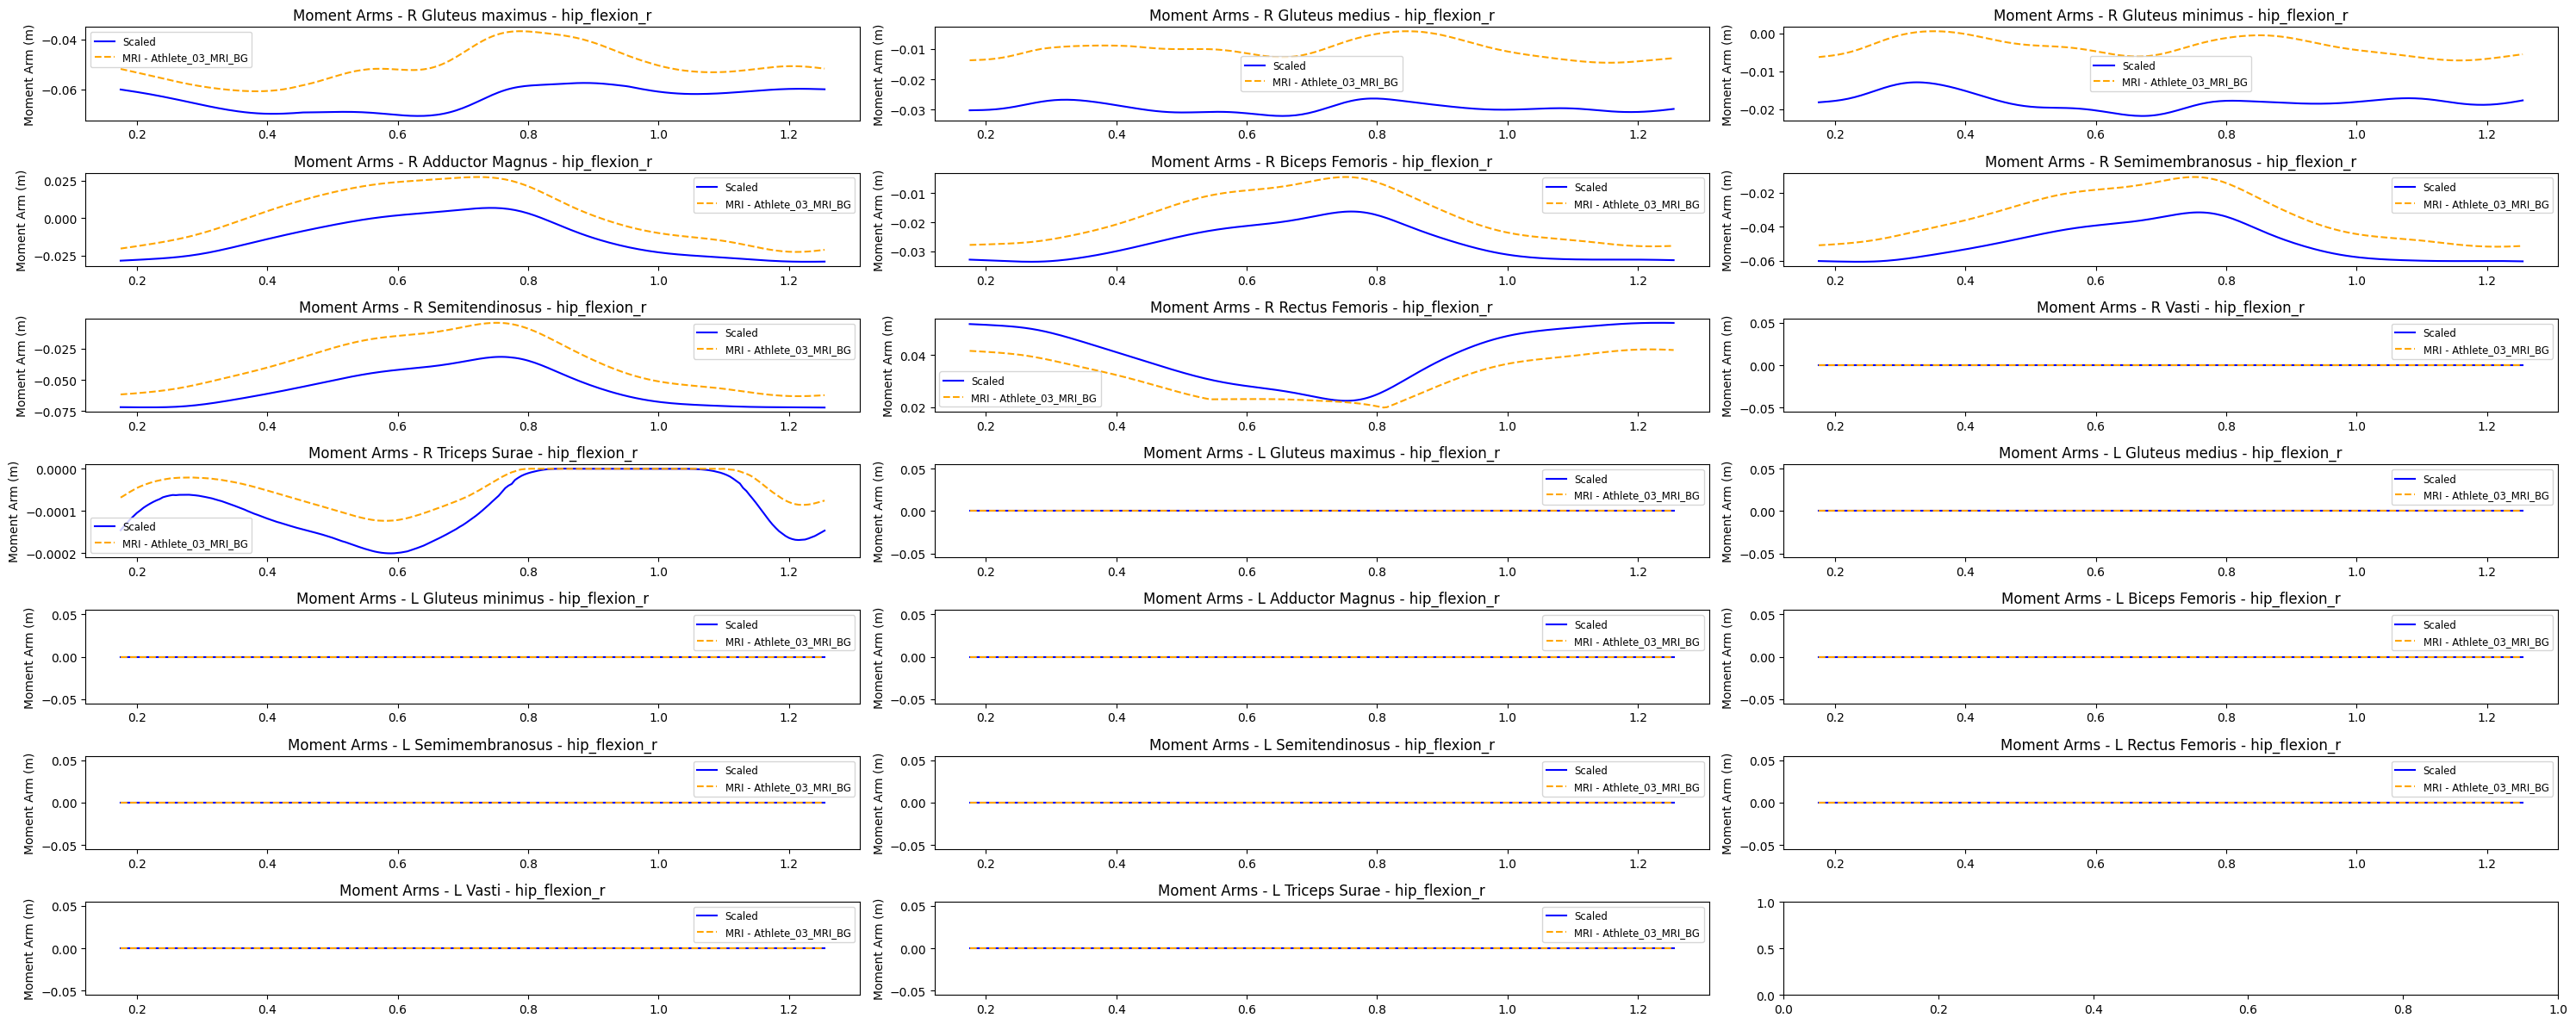

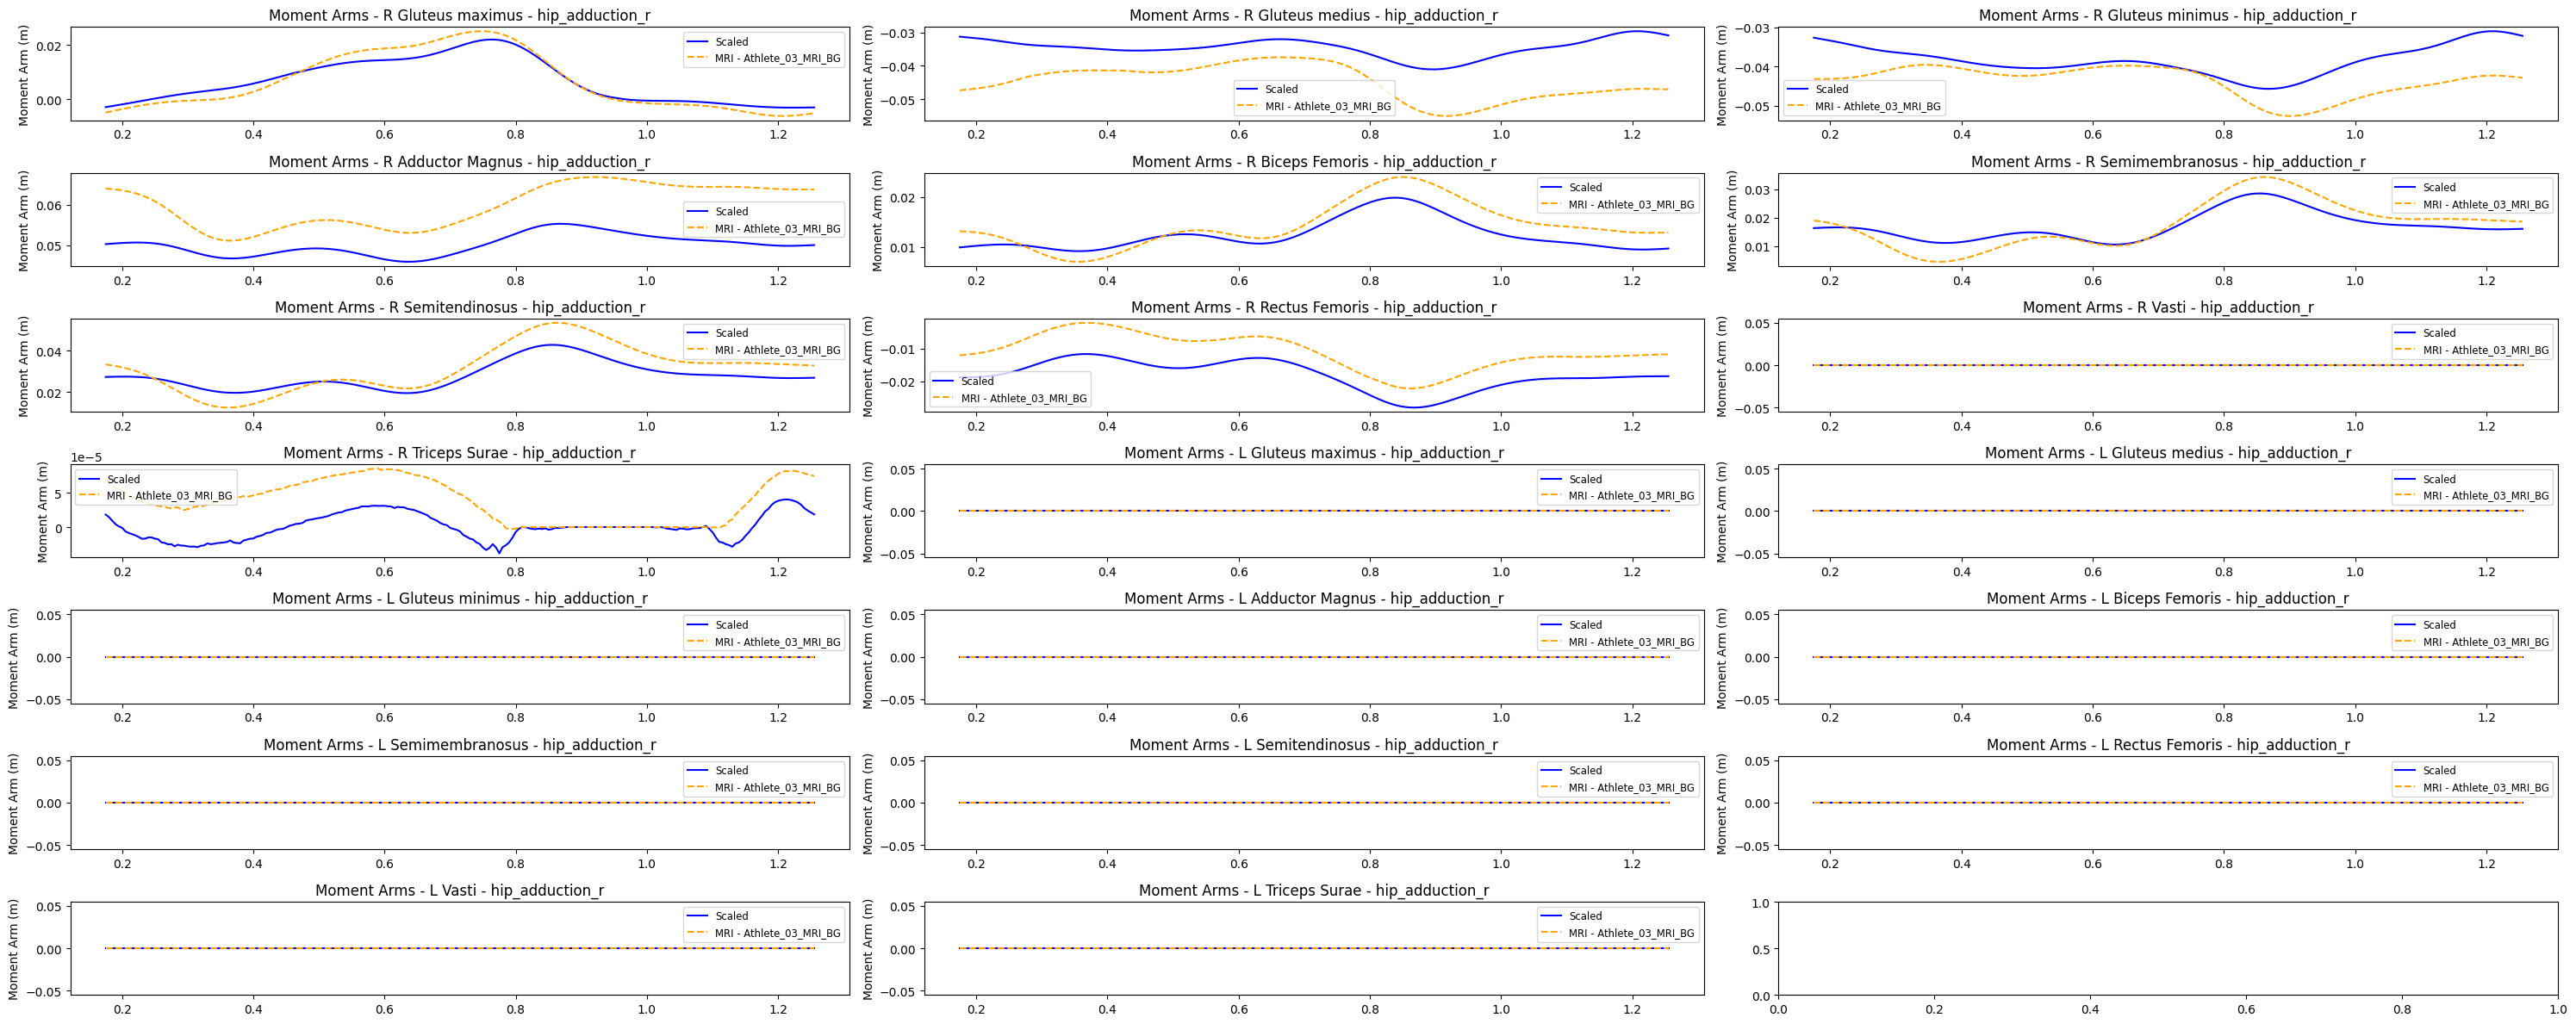

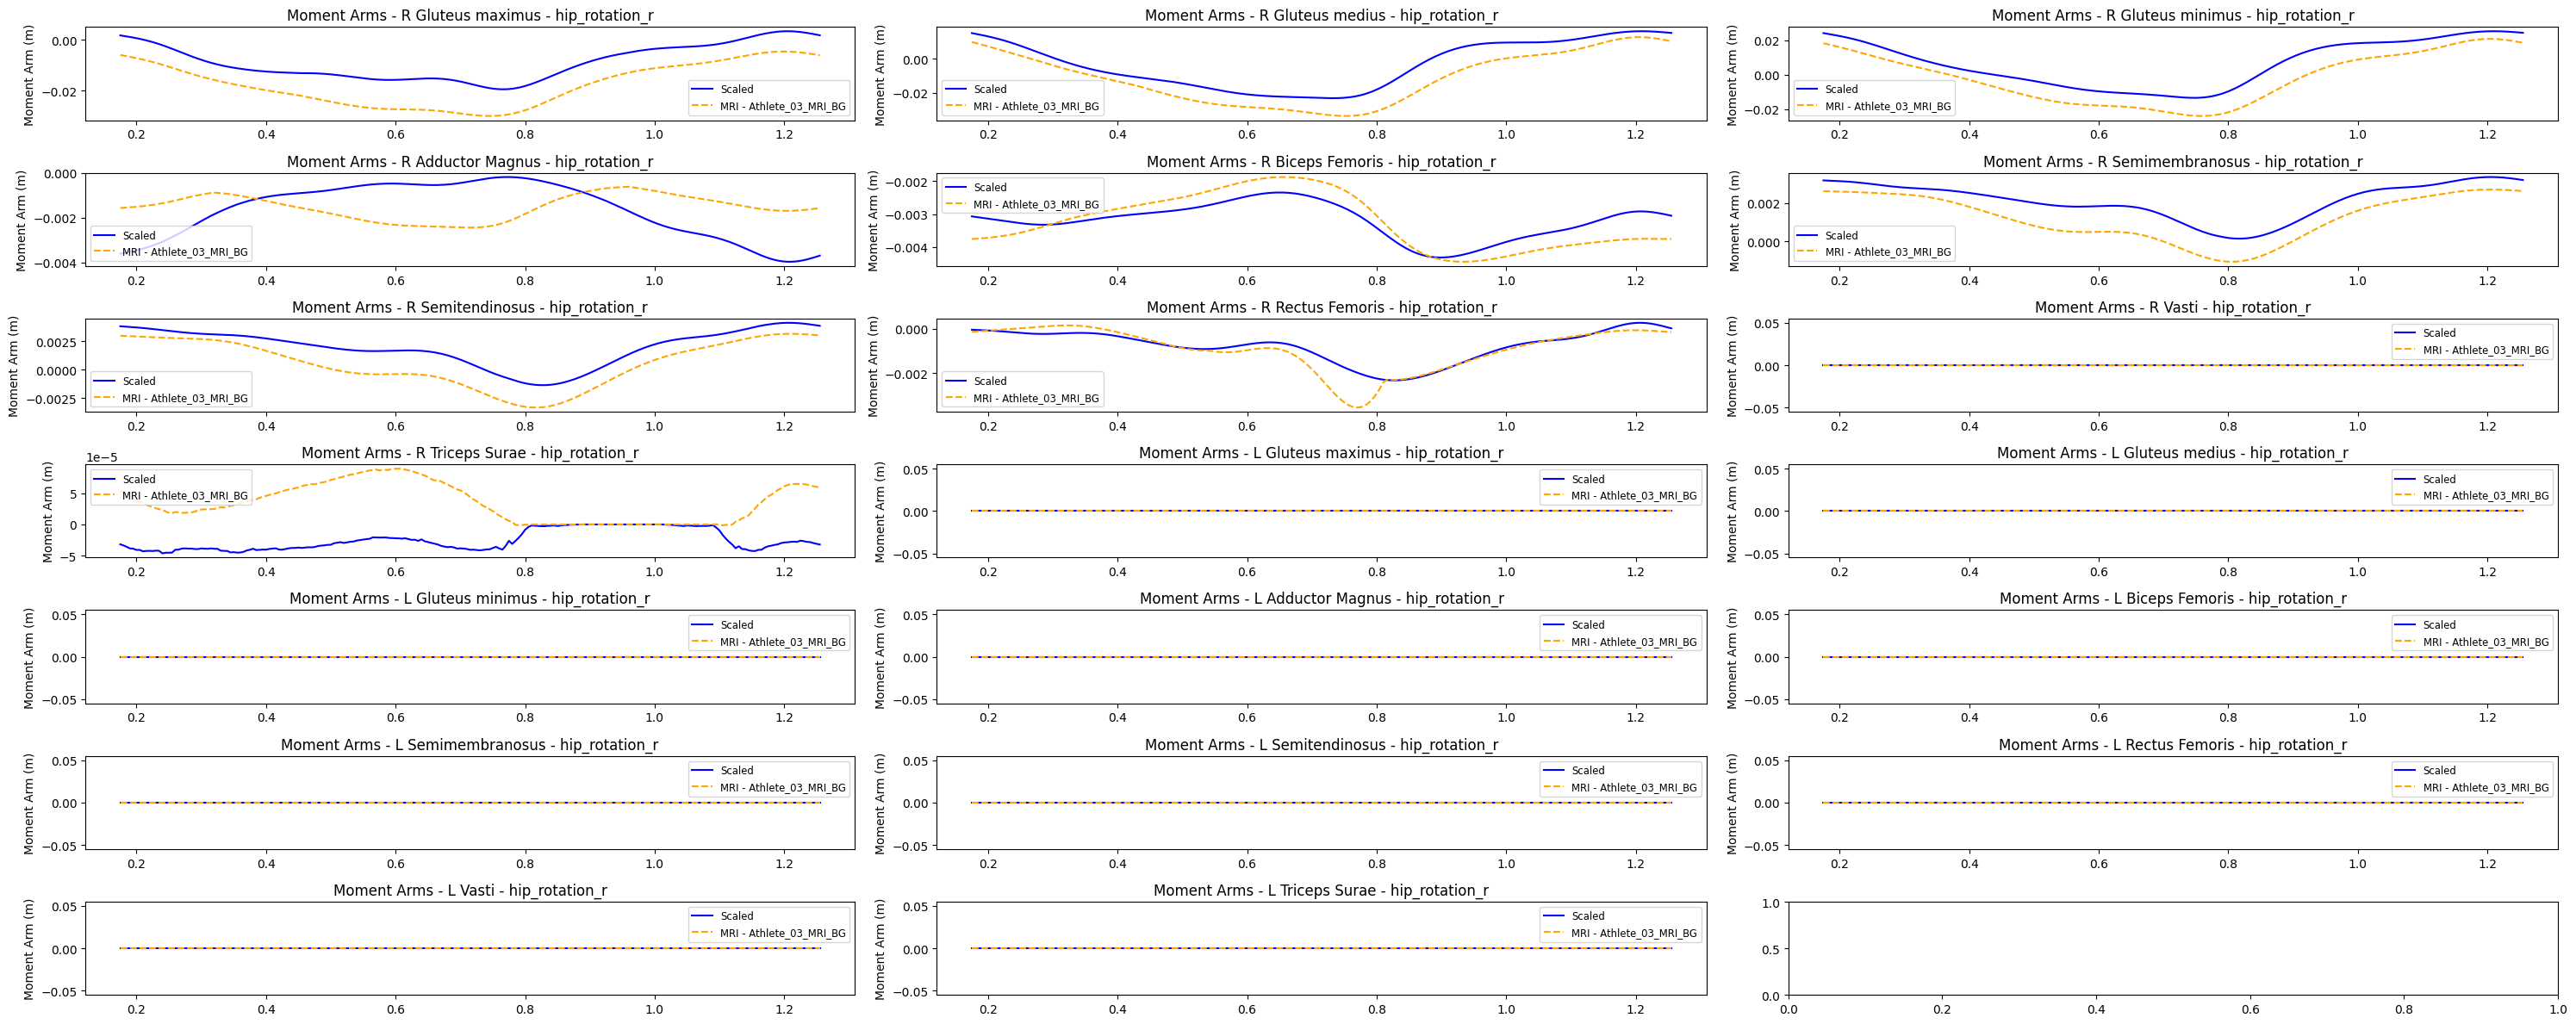

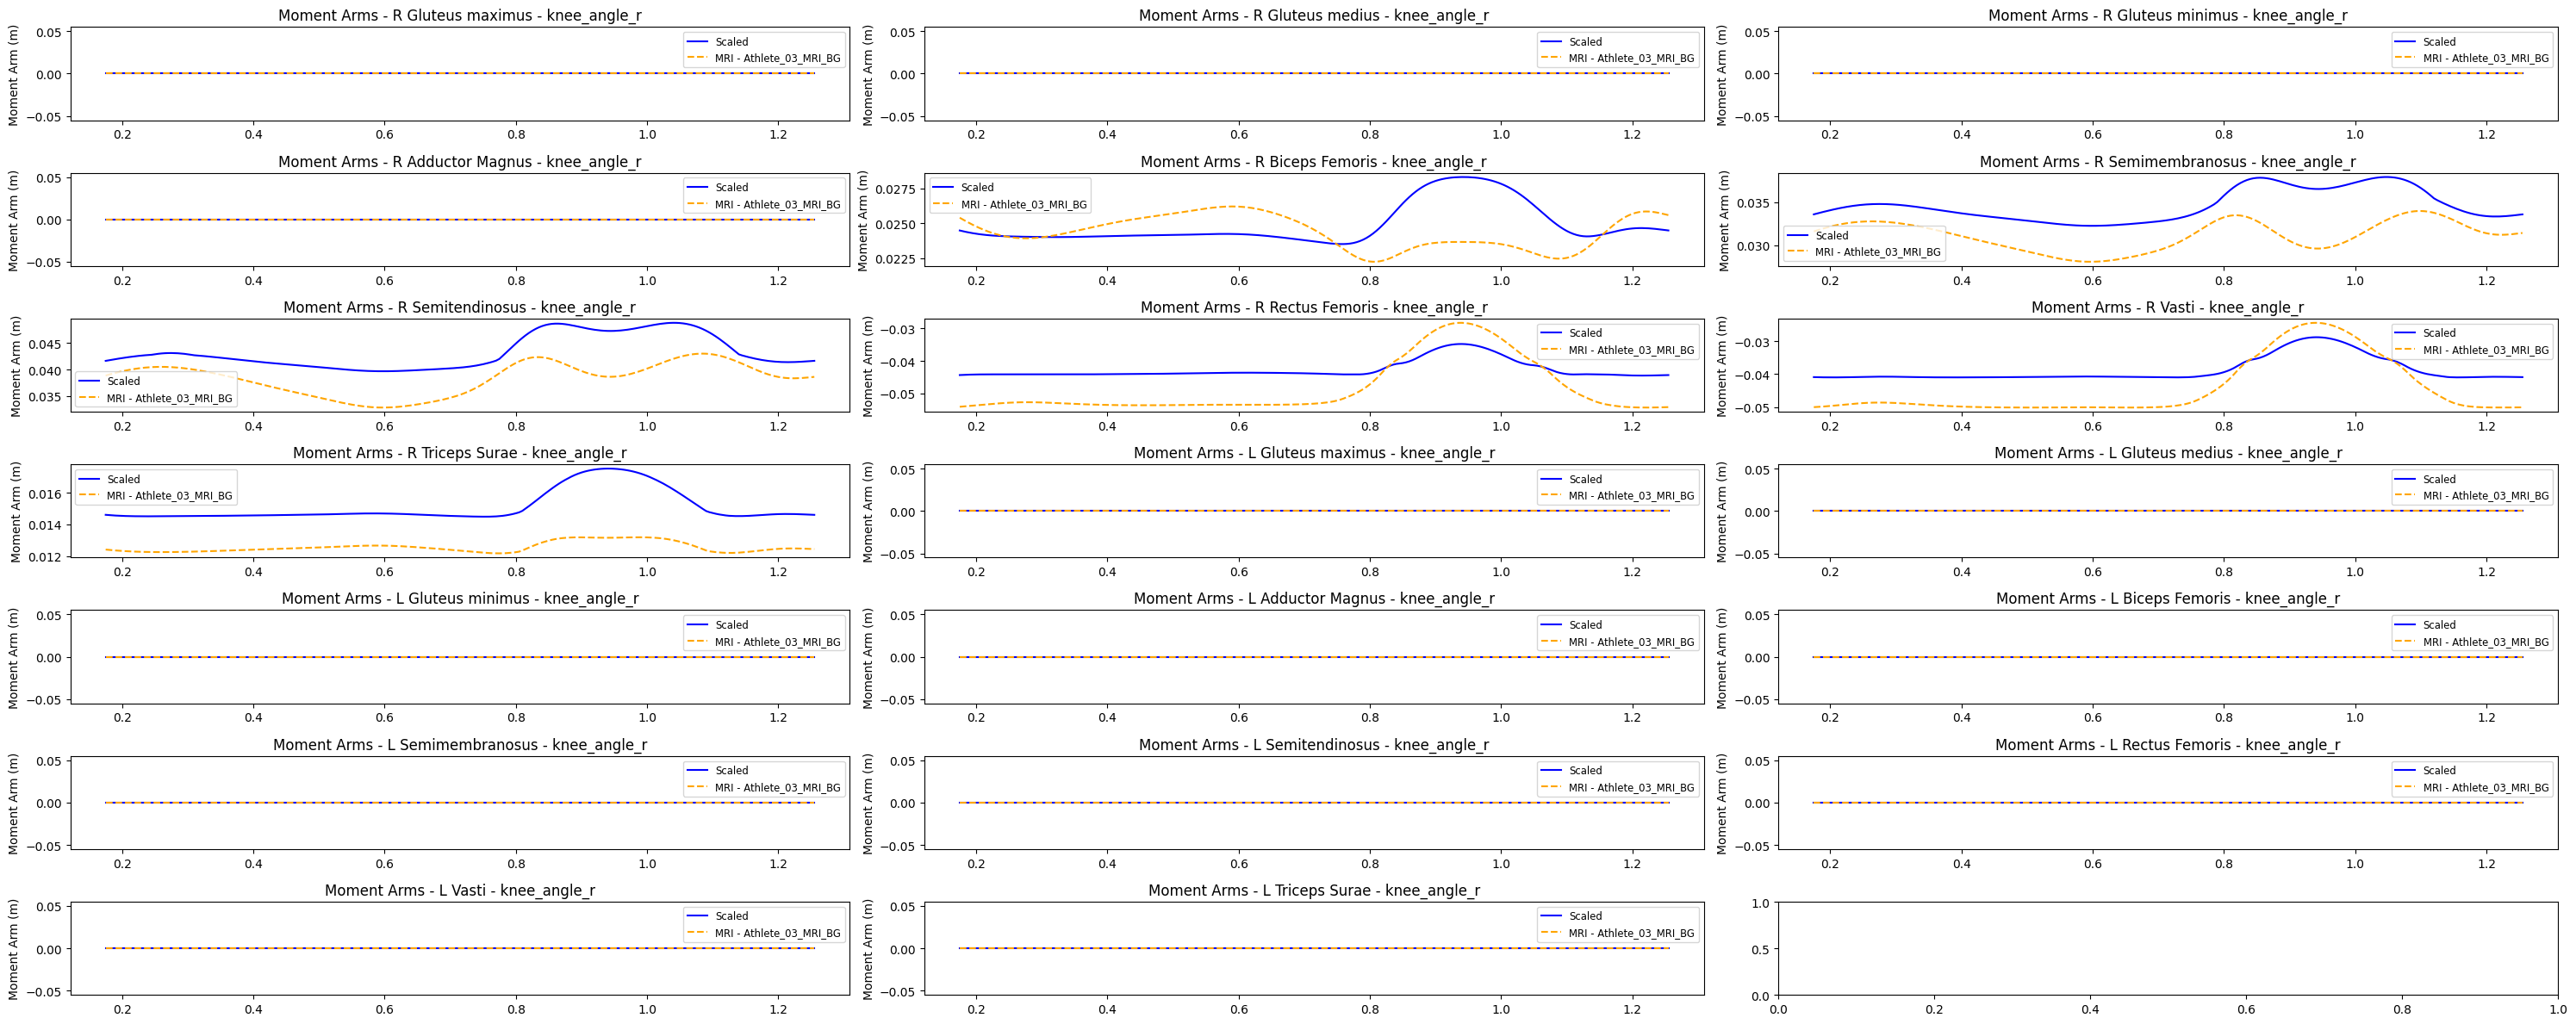

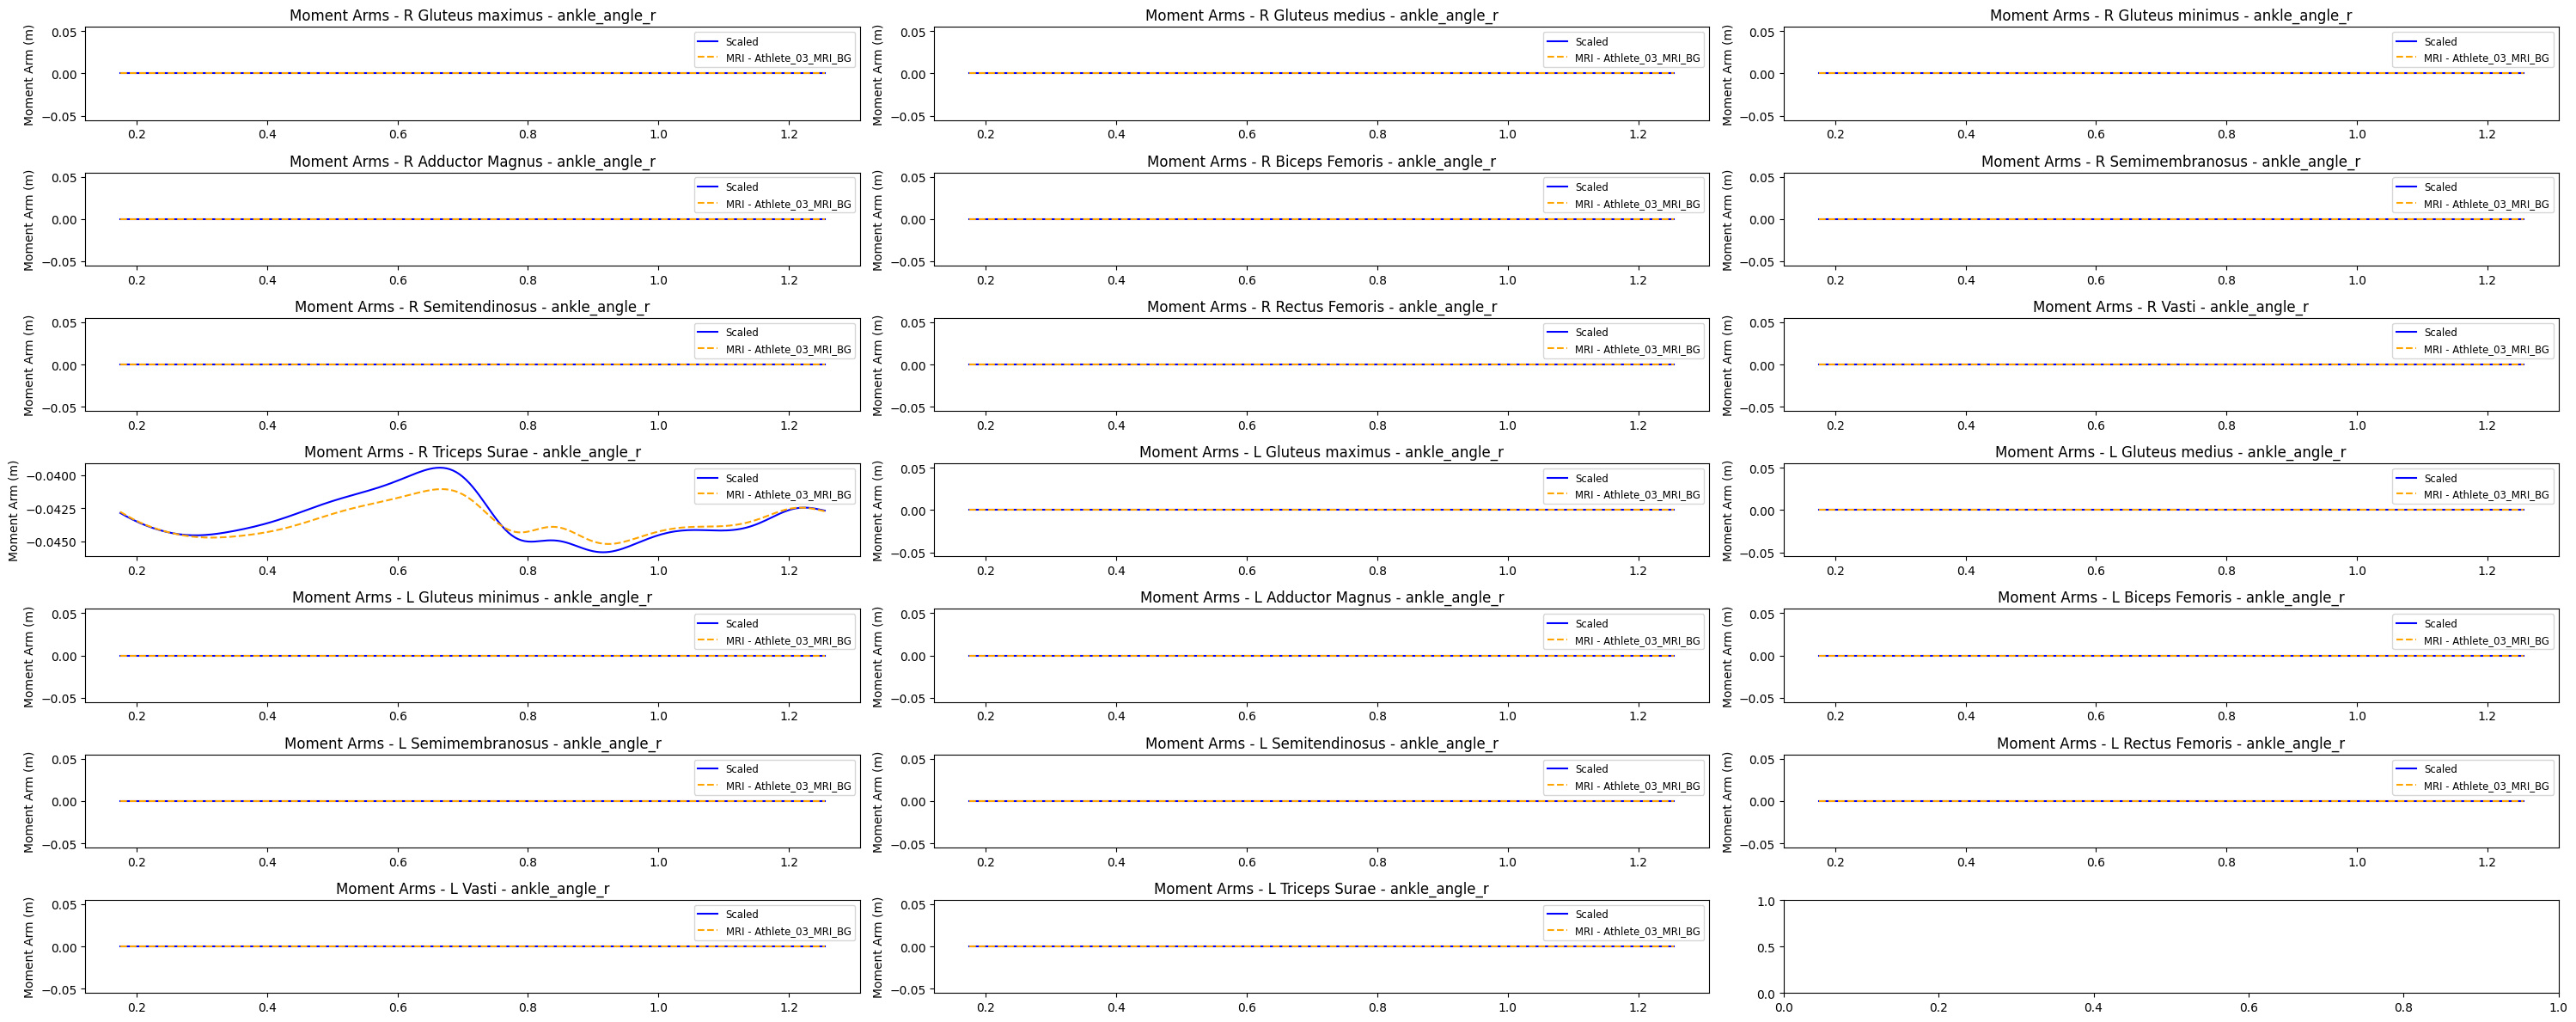

In [5]:
for dof in ik_columns:
    scale_results = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    mri_results = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    
    ncols = 3
    nrows = int(np.ceil(len(muscleGroups) / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=(30, 12))
    
    for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
        ax_row = count // ncols
        ax_col = count % ncols
        
        ax[ax_row, ax_col].plot(scale_results['time'], scale_results[muscles].mean(axis=1), label=f'Scaled', color= colors['scaled'])
        ax[ax_row, ax_col].plot(mri_results['time'], mri_results[muscles].mean(axis=1), label=f'MRI - {trial_MRI.subject}', linestyle='--', color= colors['MRI_BG'])
        ax[ax_row, ax_col].set_title(f'Moment Arms - {muscleGroup} - {dof}')
        ax[ax_row, ax_col].set_ylabel('Moment Arm (m)')
        ax[ax_row, ax_col].legend(fontsize='small')
        
        if count > len(muscleGroups)-1:
            ax[ax_row, ax_col].xticklabels([])


    plt.tight_layout()
    save_path = os.path.join(results_dir, f'ma_{trialName}_{dof}.png')
    plt.savefig(save_path)
    print(f"MA comparison plot saved: {save_path}")

## Norm Fibre lengths

In [ ]:
ceinms_folder = os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms.split('\\')[0])
ceinms_scaled = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

ceinms_folder = os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms.split('\\')[0])
ceinms_MRI = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['scaled CEINMS', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    
    # CEINMS scaled
    ax[count].plot(ceinms_scaled['time'], ceinms_scaled[muscles].mean(axis=1), label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # MRI CEINMS
    ax[count].plot(ceinms_MRI['time'], ceinms_MRI[muscles].mean(axis=1), label=labels[1], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        handles, labels = ax[count].get_legend_handles_labels()
        handles = [handles[0], handles[1]]
        labels = [labels[0], labels[1]]
        ax[count].legend(handles, labels)
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
        
plt.tight_layout()
save_path = os.path.join(results_dir, f'norm_fibre_lengths_{trialName}.png')
plt.savefig(save_path)
print(f"Norm Fibre Lengths comparison plot saved: {save_path}")


## Plot Muscle forces

Plotting muscle forces for: ['glmax1_r', 'glmax2_r', 'glmax3_r']
Plotting muscle forces for: ['glmed1_r', 'glmed2_r', 'glmed3_r']
Plotting muscle forces for: ['glmin1_r', 'glmin2_r', 'glmin3_r']
Plotting muscle forces for: ['addmagDist_r', 'addmagIsch_r', 'addmagMid_r', 'addmagProx_r']
Plotting muscle forces for: ['bflh_r', 'bfsh_r']
Plotting muscle forces for: ['semimem_r']
Plotting muscle forces for: ['semiten_r']
Plotting muscle forces for: ['recfem_r']
Plotting muscle forces for: ['vasint_r', 'vaslat_r', 'vasmed_r']
Plotting muscle forces for: ['soleus_r', 'gaslat_r', 'gasmed_r']
Plotting muscle forces for: ['glmax1_l', 'glmax2_l', 'glmax3_l']
Plotting muscle forces for: ['glmed1_l', 'glmed2_l', 'glmed3_l']
Plotting muscle forces for: ['glmin1_l', 'glmin2_l', 'glmin3_l']
Plotting muscle forces for: ['addmagDist_l', 'addmagIsch_l', 'addmagMid_l', 'addmagProx_l']
Plotting muscle forces for: ['bflh_l', 'bfsh_l']
Plotting muscle forces for: ['semimem_l']
Plotting muscle forces for: ['s

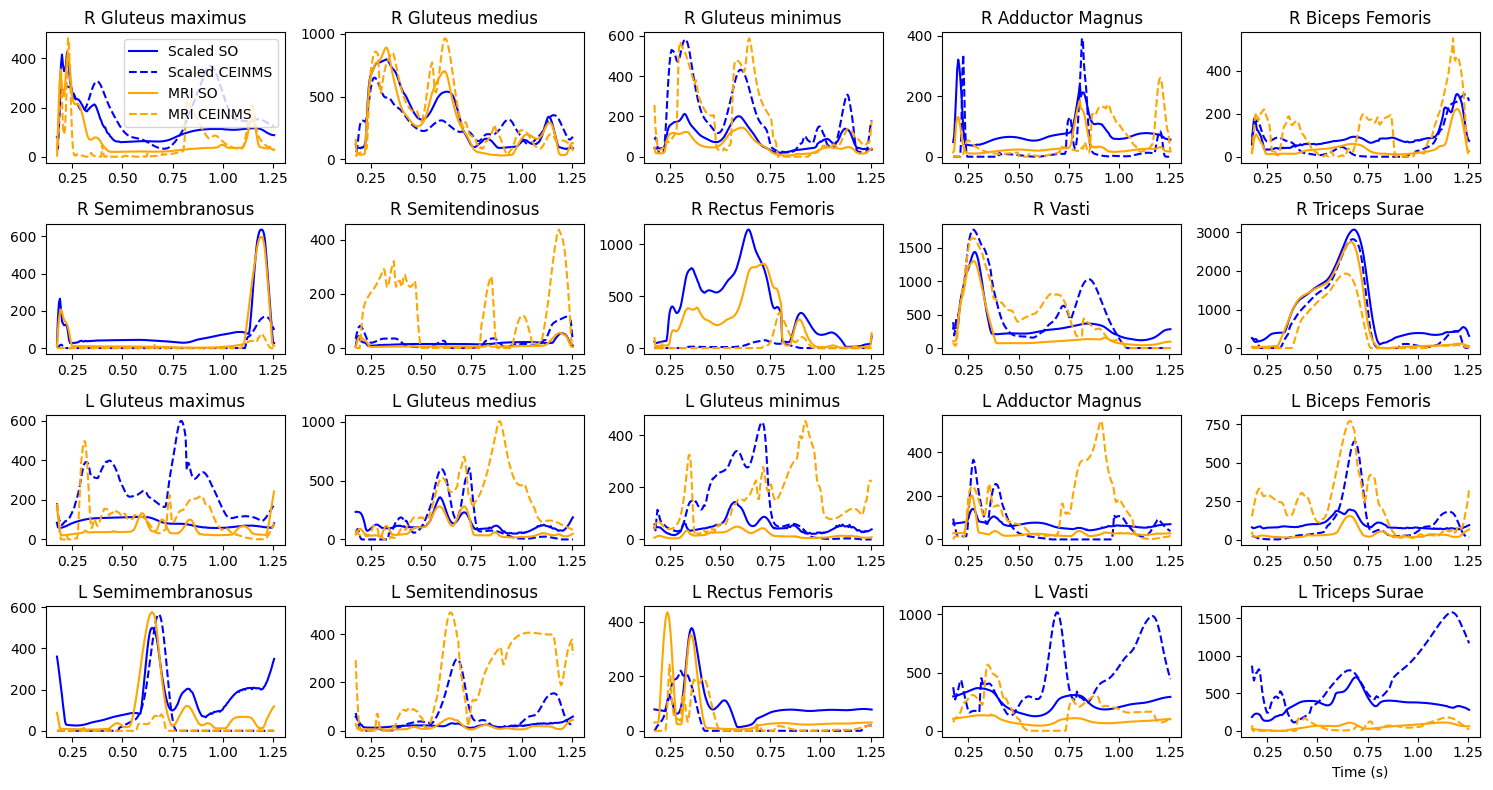

In [6]:

mf_scaled_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.so_forces))
mf_scaled_CEINMS = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms))
mf_MRI_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.so_forces))
mf_MRI_CEINMS = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms))

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['Scaled SO', 'Scaled CEINMS', 'MRI SO', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    # SO scaled
    sum_forces = mf_scaled_so[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_so['time'], sum_forces, label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # CEINMS scaled
    sum_forces = mf_scaled_CEINMS[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_CEINMS['time'], sum_forces, label=labels[1], color=colors['scaled'], linestyle='--')
    
    # MRI so
    sum_forces = mf_MRI_so[muscles].sum(axis=1)
    ax[count].plot(mf_MRI_so['time'], sum_forces, label=labels[2], color=colors['MRI_BG'])
    
    # MRI CEINMS
    ax[count].plot(mf_MRI_CEINMS['time'], mf_MRI_CEINMS[muscles].sum(axis=1), label=labels[3], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        ax[count].legend()
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_{trialName}.png')
plt.savefig(save_path)
print(f"Muscle forces comparison plot saved: {save_path}")

## Plot JRA

JRA comparison plot saved: c:\Git\powerlifing_model\results\Compare_models\jra_Walking_02.png


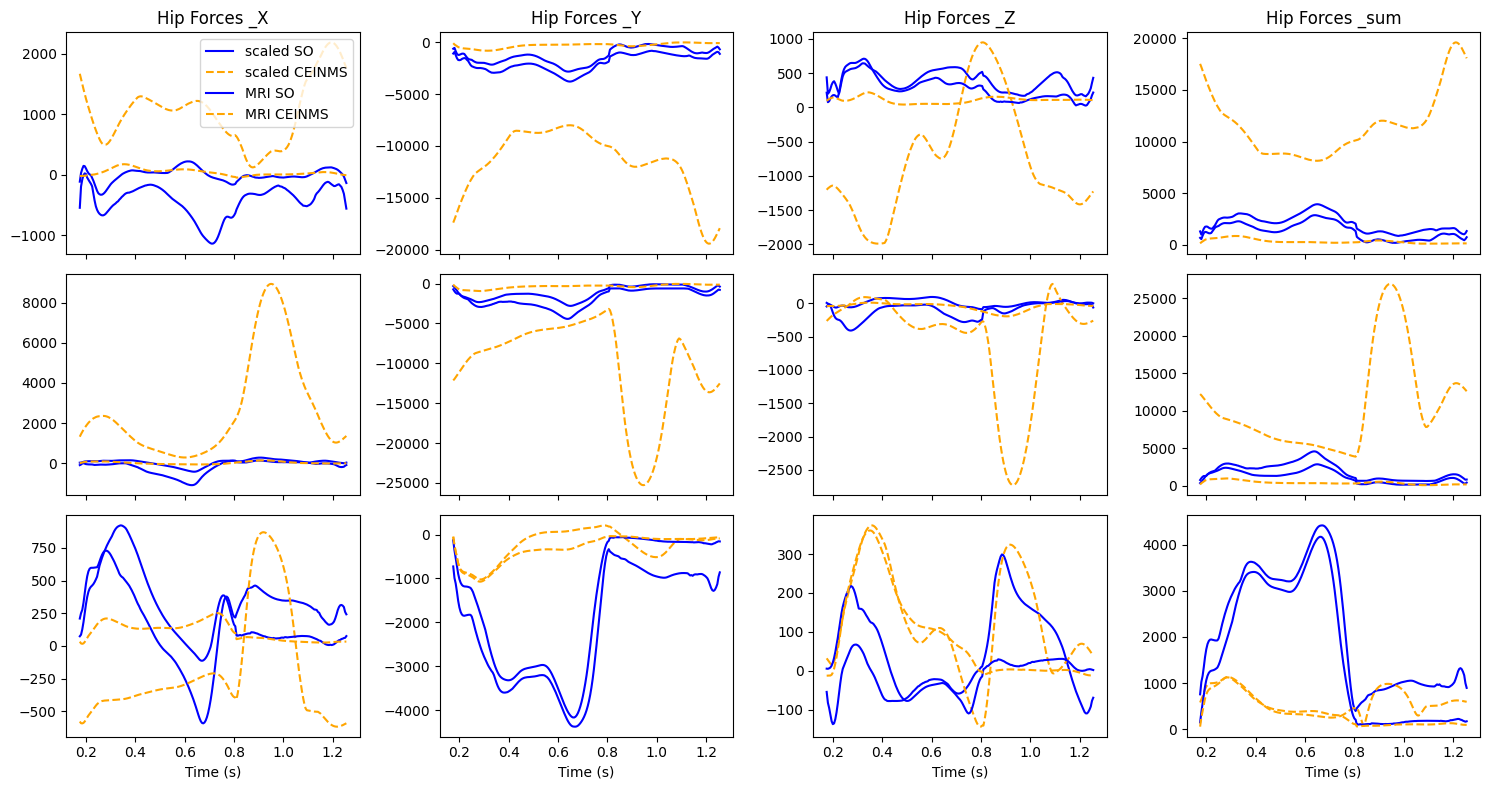

In [8]:
import numpy as np
    

jra_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra))
jra_ceinms = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_ceinms))

jra_mri_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra))
jra_mri_ceinms = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['scaled SO', 'scaled CEINMS', 'MRI SO', 'MRI CEINMS']
lineStyles = ['-', '--', '-', '--']
count = -1
for df in [jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms]:
    count += 1
    
    if count == 0 or count == 2:
        color = colors['scaled']
    else:
        color = colors['MRI_BG']
    # plot Hip first row    
    x = df['hip_r_on_femur_r_in_femur_r_fx']
    y = df['hip_r_on_femur_r_in_femur_r_fy']
    z = df['hip_r_on_femur_r_in_femur_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 1].plot(df['time'], y, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 2].plot(df['time'], z, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 3].plot(df['time'], sum, label=labels[count], color=color, linestyle=lineStyles[count])
    
    ax[0, 0].set_title('Hip Forces _X')
    ax[0, 1].set_title('Hip Forces _Y')
    ax[0, 2].set_title('Hip Forces _Z')
    ax[0, 3].set_title('Hip Forces _sum')
    
    # plot Hip first row
    x = df['walker_knee_r_on_tibia_r_in_tibia_r_fx']
    y = df['walker_knee_r_on_tibia_r_in_tibia_r_fy']
    z = df['walker_knee_r_on_tibia_r_in_tibia_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[1, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[1, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[1, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    # plot Ankle last row
    x = df['ankle_r_on_talus_r_in_talus_r_fx']
    y = df['ankle_r_on_talus_r_in_talus_r_fy']
    z = df['ankle_r_on_talus_r_in_talus_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[2, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[2, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[2, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    if count == len([jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms])-1:
        ax[2, 0].set_xlabel('Time (s)')
        ax[2, 1].set_xlabel('Time (s)')
        ax[2, 2].set_xlabel('Time (s)')
        ax[2, 3].set_xlabel('Time (s)')
    else:
        # remove x labels for other rows
        for i in range(4):
            ax[0, i].set_xticklabels([])
            ax[1, i].set_xticklabels([])
            
        
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    

## Summary plot

# Plot 3 tasks (compare Scaled vs MRI)

## Initiate data

In [9]:

trialName = 'Walking_02'
walking_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName))
walking_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName))

squat_trial = 'Squat_bw_01'
squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', squat_trial))
squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', squat_trial))

weighted_squat_tiral = 'Squat_35kg_01'
weighted_squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', weighted_squat_tiral))
weighted_squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', weighted_squat_tiral))

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'Compare_models')

Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Squat_bw_01\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_bw_01\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Squat_35kg_01\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model\simulations\Athlete_03_MRI_BG\25_03_31\Squat_35kg_01\trial_settings.xml


## IK

In [ ]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.ik))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.ik))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.ik))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.ik)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.ik))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.ik))

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].legend()
ax[0, 0].set_ylabel('Angle (degrees)')

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Angle (degrees)')
ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Angle (degrees)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Angle (degrees)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Angle (degrees)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Angle (degrees)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['hip_flexion_r'], label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['hip_flexion_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')    
ax[2, 0].set_ylabel('Angle (degrees)')
ax[2, 0].set_xlabel('Time (s)') 

ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['knee_angle_r'], label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['knee_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Angle (degrees)')
ax[2, 1].set_xlabel('Time (s)') 

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['ankle_angle_r'], label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['ankle_angle_r'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Angle (degrees)')
ax[2, 2].set_xlabel('Time (s)') 

save_path = os.path.join(results_dir, f'ik_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"IK comparison plot saved: {save_path}")





## ID 

In [ ]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.id))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.id))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.id))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.id)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.id))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.id))

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].legend()
ax[0, 0].set_ylabel('Moment (Nm)')

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Moment (Nm)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Moment (Nm)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Moment (Nm)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Moment (Nm)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Moment (Nm)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['hip_flexion_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['hip_flexion_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Moment (Nm)')
ax[2, 0].set_xlabel('Time (s)')

ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['knee_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['knee_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Moment (Nm)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results['ankle_angle_r_moment'], label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results['ankle_angle_r_moment'], label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Moment (Nm)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'id_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"ID comparison plot saved: {save_path}")




## Moment arms

In [ ]:

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto')) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))

hip_extensors = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r piri_r semimem_r semiten_r'.split()
hip_flexors = 'grac_r iliacus_r psoas_r recfem_r sart_r tfl_r'.split()
knee_extensors = 'recfem_r vasint_r vaslat_r vasmed_r'.split()
knee_flexors = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r sart_r semimem_r semiten_r'.split()
ankle_plantarflexors = 'gaslat_r gasmed_r soleus_r'.split()
ankle_dorsiflexors = 'edl_r ehl_r fdl_r fhl_r perbrev_r perlong_r tibant_r tibpost_r'.split()

trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]

row = -1

for trial_name, scaled_trial, mri_trial in trials:

    row += 1
  
    # --------- Hip flexion plots
    scaled_retults = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))
    mri_results = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.ma, '_MuscleAnalysis_MomentArm_hip_flexion_r.sto'))

    ax[row, 0].plot(scaled_retults['time'], scaled_retults[hip_flexors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='-')
    ax[row, 0].plot(scaled_retults['time'], scaled_retults[hip_extensors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='--')

    ax[row, 0].plot(mri_results['time'], mri_results[hip_flexors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='-')
    ax[row, 0].plot(mri_results['time'], mri_results[hip_extensors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='--')

    ax[row, 0].set_title(f'{trial_name} - Hip')
    ax[row, 0].set_ylabel('Moment Arm (m)')
    if row == 0: ax[row, 0].legend()
    if row == 2: ax[row, 0].set_xlabel('Time (s)')

    # ----------- Knee plots
    scaled_retults = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.ma, '_MuscleAnalysis_MomentArm_knee_angle_r.sto'))
    mri_results = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.ma, '_MuscleAnalysis_MomentArm_knee_angle_r.sto'))

    ax[row, 1].plot(scaled_retults['time'], scaled_retults[knee_extensors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='-')
    ax[row, 1].plot(scaled_retults['time'], scaled_retults[knee_flexors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='--')
    ax[row, 1].plot(mri_results['time'], mri_results[knee_extensors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='-')
    ax[row, 1].plot(mri_results['time'], mri_results[knee_flexors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='--')
    ax[row, 1].set_title(f'{trial_name} - Knee')
    ax[row, 1].set_ylabel('Moment Arm (m)')
    if row == 2: ax[row, 1].set_xlabel('Time (s)')


    # ----------- Ankle plots
    scaled_retults = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.ma, '_MuscleAnalysis_MomentArm_ankle_angle_r.sto'))
    mri_results = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.ma, '_MuscleAnalysis_MomentArm_ankle_angle_r.sto'))

    ax[row, 2].plot(scaled_retults['time'], scaled_retults[ankle_plantarflexors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='-')
    ax[row, 2].plot(scaled_retults['time'], scaled_retults[ankle_dorsiflexors].mean(axis=1), label='Scaled', color=colors['scaled'], linestyle='--')
    ax[row, 2].plot(mri_results['time'], mri_results[ankle_plantarflexors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='-')
    ax[row, 2].plot(mri_results['time'], mri_results[ankle_dorsiflexors].mean(axis=1), label='MRI_BG', color=colors['MRI_BG'], linestyle='--')
    ax[row, 2].set_title(f'{trial_name} - Ankle')
    ax[row, 2].set_ylabel('Moment Arm (m)')
    if row == 2: ax[row, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'ma_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"MA comparison plot saved: {save_path}")


## Muscle forces SO

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.so_forces))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.so_forces))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.so_forces))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.so_forces)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.so_forces))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.so_forces))

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Force (N)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Force (N)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Force (N)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Force (N)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Force (N)')


ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Force (N)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Force (N)')
ax[2, 2].set_xlabel('Time (s)')


# change font size
plt.rcParams.update({'font.size': font_size})

save_path = os.path.join(results_dir, f'so_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"SO comparison plot saved: {save_path}")



## Muscle forces CEINMS

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_forces_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_forces_ceinms))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra_forces_ceinms))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra_forces_ceinms)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra_forces_ceinms))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra_forces_ceinms))

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

# walking row
ax[0, 0].plot(walking_scaled_results['time'], walking_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], walking_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], walking_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], walking_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')
ax[0, 1].set_ylabel('Force (N)')

ax[0, 2].plot(walking_scaled_results['time'], walking_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], walking_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')
ax[0, 2].set_ylabel('Force (N)')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')
ax[1, 1].set_ylabel('Force (N)')

ax[1, 2].plot(squat_scaled_results['time'], squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')
ax[1, 2].set_ylabel('Force (N)')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[hip_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[hip_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Force (N)')
    
ax[2, 1].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[knee_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[knee_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')
ax[2, 1].set_ylabel('Force (N)')
ax[2, 1].set_xlabel('Time (s)')

ax[2, 2].plot(weighted_squat_scaled_results['time'], weighted_squat_scaled_results[ankle_muscles].sum(axis=1), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], weighted_squat_MRI_results[ankle_muscles].sum(axis=1), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')
ax[2, 2].set_ylabel('Force (N)')
ax[2, 2].set_xlabel('Time (s)')


save_path = os.path.join(results_dir, f'ceinms_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"CEINMS comparison plot saved: {save_path}")


## Muscle forces 4 lines

In [ ]:
Muscle_GroupsR = { 'Adductors': ['addbrev_r','addlong_r','addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r','grac_r'],
    'Hamstrings': ['bflh_r','semimem_r','semiten_r','bfsh_r'],
    'Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
    'Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
    'Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'],
    'Hip flexors':['sart_r','recfem_r','tfl_r','iliacus_r','psoas_r'],            
    'Triceps Surae':['soleus_r','gaslat_r','gasmed_r'],
    'Vasti':['vasint_r','vaslat_r','vasmed_r'],
    }

Muscle_GroupsL = { 'Adductors': ['addbrev_l', 'addlong_l', 'addmagDist_l', 'addmagIsch_l', 'addmagMid_l', 'addmagProx_l', 'grac_l'],
    'Hamstrings': ['bflh_l', 'semimem_l', 'semiten_l', 'bfsh_l'],
    'Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
    'Gluteus medius': ['glmed1_l', 'glmed2_l', 'glmed3_l'],
    'Gluteus minimus': ['glmin1_l', 'glmin2_l', 'glmin3_l'],
    'Hip flexors': ['sart_l', 'recfem_l', 'tfl_l', 'iliacus_l', 'psoas_l'],
    'Triceps Surae': ['soleus_l', 'gaslat_l', 'gasmed_l'],
    'Vasti': ['vasint_l', 'vaslat_l', 'vasmed_l'],
}

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]

fig, ax = plt.subplots(nrows=len(trials), ncols=len(Muscle_GroupsR), figsize=(30, 15))

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_forces))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_forces))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]
        
        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].sum(axis=1)
            mri_so_avg = mri_so[muscles_r].sum(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].sum(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].sum(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].sum(axis=1) + scaled_so[muscles_l].sum(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].sum(axis=1) + mri_so[muscles_l].sum(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].sum(axis=1) + scaled_ceinms[muscles_l].sum(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].sum(axis=1) + mri_ceinms[muscles_l].sum(axis=1)) / 2
        
        # Plot
        ax[trial_idx, idx].plot(scaled_so['time'], scaled_so_avg, label='Scaled SO', color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(mri_so['time'], mri_so_avg, label='MRI SO', color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(scaled_ceinms['time'], scaled_ceinms_avg, label='Scaled CEINMS', color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, idx].plot(mri_ceinms['time'], mri_ceinms_avg, label='MRI CEINMS', color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences and SD
        diff_so_scaled_vs_mri = scaled_so_avg - mri_so_avg
        diff_so_scaled_vs_ceinms_scaled = scaled_so_avg - scaled_ceinms_avg
        diff_ceinms_scaled_vs_mri = scaled_ceinms_avg - mri_ceinms_avg
        
        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()
        
        mean_diff_1 = (diff_so_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_1 = (diff_so_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_2 = (diff_so_scaled_vs_ceinms_scaled.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_2 = (diff_so_scaled_vs_ceinms_scaled.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_3 = (diff_ceinms_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_3 = (diff_ceinms_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {mean_diff_1:.1f}±{std_diff_1:.1f}%\nSO_scaled vs CEINMS_scaled: {mean_diff_2:.1f}±{std_diff_2:.1f}%\nCEINMS_scaled vs MRI_CEINMS: {mean_diff_3:.1f}±{std_diff_3:.1f}%'
        ax[trial_idx, idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, idx].transAxes, 
                                fontsize=7, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}')
        ax[trial_idx, idx].set_ylabel('Force (N)')
        
        if trial_idx == 2:
            ax[trial_idx, idx].set_xlabel('Time (s)')
        
        if trial_idx == 0 and idx == 0:
            ax[trial_idx, idx].legend(fontsize=10)

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_all_trials.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle forces comparison saved: {save_path}")

In [ ]:

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]


results_data = []
fig, ax = plt.subplots(nrows=3, ncols=len(Muscle_GroupsR), figsize=(30, 15))
for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_forces))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_forces))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]

        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].sum(axis=1)
            mri_so_avg = mri_so[muscles_r].sum(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].sum(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].sum(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].sum(axis=1) + scaled_so[muscles_l].sum(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].sum(axis=1) + mri_so[muscles_l].sum(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].sum(axis=1) + scaled_ceinms[muscles_l].sum(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].sum(axis=1) + mri_ceinms[muscles_l].sum(axis=1)) / 2
        
        
        # Calculate mean differences and std
        diff_so_scaled_vs_mri = (scaled_so_avg.mean() - mri_so_avg.mean())
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg.mean() - scaled_ceinms_avg.mean())
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg.mean() - mri_ceinms_avg.mean())
        diff_so_scaled_vs_ceinms_mri = (scaled_so_avg.mean() - mri_ceinms_avg.mean())

        std_diff_so_scaled_vs_mri = (scaled_so_avg - mri_so_avg).std()
        std_diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg - scaled_ceinms_avg).std()
        std_diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg - mri_ceinms_avg).std()
        std_diff_so_scaled_vs_ceinms_mri = (scaled_so_avg - mri_ceinms_avg).std()

        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()

        # Convert to percentage of range
        diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_mri_pct = (diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100
        
        std_diff_so_scaled_vs_mri_pct = (std_diff_so_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_scaled_pct = (std_diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        std_diff_ceinms_scaled_vs_mri_pct = (std_diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_mri_pct = (std_diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100

        # Store results
        results_data.append({
            'Trial': trial_name,
            'Muscle_Group': group_name,
            'Mean_Diff_SO_scaled_vs_SO_MRI': diff_so_scaled_vs_mri,
            'Std_Diff_SO_scaled_vs_SO_MRI': std_diff_so_scaled_vs_mri,
            'Mean_Diff_SO_scaled_vs_CEINMS_scaled': diff_so_scaled_vs_ceinms_scaled,
            'Std_Diff_SO_scaled_vs_CEINMS_scaled': std_diff_so_scaled_vs_ceinms_scaled,
            'Mean_Diff_CEINMS_scaled_vs_MRI_CEINMS': diff_ceinms_scaled_vs_mri,
            'Std_Diff_CEINMS_scaled_vs_MRI_CEINMS': std_diff_ceinms_scaled_vs_mri,
            'Mean_Diff_SO_scaled_vs_MRI_CEINMS': diff_so_scaled_vs_ceinms_mri,
            'Std_Diff_SO_scaled_vs_MRI_CEINMS': std_diff_so_scaled_vs_ceinms_mri
        })
        
        # Create bar plot
        x_pos = [0, 1, 2, 3]
        differences = [diff_so_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_scaled_pct, diff_ceinms_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_mri_pct]
        labels = ['SO_scaled vs\nSO_MRI', 'SO_scaled vs\nCEINMS_scaled', 'CEINMS_scaled vs\nMRI_CEINMS', 'SO_scaled vs\nMRI_CEINMS']
        
        bars = ax[trial_idx, idx].bar(x_pos, differences, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        
        # Add error bars with standard deviation
        std_errors = [std_diff_so_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_scaled_pct, std_diff_ceinms_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_mri_pct]
        ax[trial_idx, idx].errorbar(x_pos, differences, yerr=std_errors, fmt='none', ecolor='black', capsize=3, capthick=1)
        
        # Add horizontal line at y=0
        ax[trial_idx, idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        ax[trial_idx, idx].set_xticks(x_pos)
        ax[trial_idx, idx].set_xticklabels(labels, fontsize=8, rotation=0)
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}', fontsize=10)
        ax[trial_idx, idx].set_ylabel('Mean Difference (%)', fontsize=9)
        
        if trial_idx == 2:
            ax[trial_idx, idx].set_xlabel('Comparison', fontsize=9)

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_differences_bar_plots.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle forces differences bar plots saved: {save_path}")

# Create DataFrame and save to CSV
results_df = pd.DataFrame(results_data)
csv_path = os.path.join(results_dir, 'muscle_forces_differences_statistics.csv')
results_df.to_csv(csv_path, index=False)
print(f"Statistics saved to: {csv_path}")

## Muscle activations

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=len(Muscle_GroupsR), figsize=(30, 15))

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_activations))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_activations))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms.replace('MuscleForces.sto','AdjustedEmgs.sto')))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms.replace('MuscleForces.sto','AdjustedEmgs.sto')))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]
        
        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].mean(axis=1)
            mri_so_avg = mri_so[muscles_r].mean(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].mean(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].mean(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].mean(axis=1) + scaled_so[muscles_l].mean(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].mean(axis=1) + mri_so[muscles_l].mean(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].mean(axis=1) + scaled_ceinms[muscles_l].mean(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].mean(axis=1) + mri_ceinms[muscles_l].mean(axis=1)) / 2
        
        # Plot
        ax[trial_idx, idx].plot(scaled_so['time'], scaled_so_avg, label='Scaled SO', color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(mri_so['time'], mri_so_avg, label='MRI SO', color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(scaled_ceinms['time'], scaled_ceinms_avg, label='Scaled CEINMS', color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, idx].plot(mri_ceinms['time'], mri_ceinms_avg, label='MRI CEINMS', color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences and SD
        diff_so_scaled_vs_mri = scaled_so_avg - mri_so_avg
        diff_so_scaled_vs_ceinms_scaled = scaled_so_avg - scaled_ceinms_avg
        diff_ceinms_scaled_vs_mri = scaled_ceinms_avg - mri_ceinms_avg
        
        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()
        
        mean_diff_1 = (diff_so_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_1 = (diff_so_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_2 = (diff_so_scaled_vs_ceinms_scaled.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_2 = (diff_so_scaled_vs_ceinms_scaled.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_3 = (diff_ceinms_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_3 = (diff_ceinms_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {mean_diff_1:.1f}±{std_diff_1:.1f}%\nSO_scaled vs CEINMS_scaled: {mean_diff_2:.1f}±{std_diff_2:.1f}%\nCEINMS_scaled vs MRI_CEINMS: {mean_diff_3:.1f}±{std_diff_3:.1f}%'
        ax[trial_idx, idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, idx].transAxes, 
                                fontsize=7, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}')
        ax[trial_idx, idx].set_ylabel('Force (N)')
        
        if trial_idx == 2:
            ax[trial_idx, idx].set_xlabel('Time (s)')
        
        if trial_idx == 0 and idx == 0:
            ax[trial_idx, idx].legend(fontsize=10)

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_activations_all_trials.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle activations comparison (bilateral average with statistics) saved: {save_path}")

## JRF SO

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Joint Reaction Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Joint Reaction Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Joint Reaction Force (N)')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')

plt.rcParams.update({'font.size': font_size})

save_path = os.path.join(results_dir, f'jra_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")



## JRA ceinms

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_ceinms))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra_ceinms))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra_ceinms)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra_ceinms))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra_ceinms))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Moment Arm (m)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')


save_path = os.path.join(results_dir, f'jraCEINMS_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA CEINMS comparison plot saved: {save_path}")


## JRF 4 lines

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]

# Define joint columns
hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

joints = [
    ('Hip', hip),
    ('Knee', knee),
    ('Ankle', ankle)
]

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum_val = np.sqrt(x**2 + y**2 + z**2)
    return sum_val

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    for joint_idx, (joint_name, joint_cols) in enumerate(joints):
        # Calculate 3D sum for each condition
        scaled_so_jrf = sum3d(scaled_so, joint_cols)
        mri_so_jrf = sum3d(mri_so, joint_cols)
        scaled_ceinms_jrf = sum3d(scaled_ceinms, joint_cols)
        mri_ceinms_jrf = sum3d(mri_ceinms, joint_cols)
        
        # Plot
        ax[trial_idx, joint_idx].plot(scaled_so['time'], scaled_so_jrf, label='Scaled SO', 
                                       color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_so['time'], mri_so_jrf, label='MRI SO', 
                                       color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(scaled_ceinms['time'], scaled_ceinms_jrf, label='Scaled CEINMS', 
                                       color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_ceinms['time'], mri_ceinms_jrf, label='MRI CEINMS', 
                                       color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences as percentage of range
        range_scaled_so = scaled_so_jrf.max() - scaled_so_jrf.min()
        
        diff_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).mean()
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).mean()
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).mean()
        
        std_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).std()
        std_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).std()
        std_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).std()
        
        # Convert to percentage
        if range_scaled_so != 0:
            diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_scaled_so) * 100
            diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_scaled_so) * 100
            
            std_so_scaled_vs_mri_pct = (std_so_scaled_vs_mri / range_scaled_so) * 100
            std_so_scaled_vs_ceinms_scaled_pct = (std_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            std_ceinms_scaled_vs_mri_pct = (std_ceinms_scaled_vs_mri / range_scaled_so) * 100
        else:
            diff_so_scaled_vs_mri_pct = 0
            diff_so_scaled_vs_ceinms_scaled_pct = 0
            diff_ceinms_scaled_vs_mri_pct = 0
            std_so_scaled_vs_mri_pct = 0
            std_so_scaled_vs_ceinms_scaled_pct = 0
            std_ceinms_scaled_vs_mri_pct = 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {diff_so_scaled_vs_mri_pct:.1f}±{std_so_scaled_vs_mri_pct:.1f}%\n'
        text_str += f'SO_scaled vs CEINMS_scaled: {diff_so_scaled_vs_ceinms_scaled_pct:.1f}±{std_so_scaled_vs_ceinms_scaled_pct:.1f}%\n'
        text_str += f'CEINMS_scaled vs MRI_CEINMS: {diff_ceinms_scaled_vs_mri_pct:.1f}±{std_ceinms_scaled_vs_mri_pct:.1f}%'
        
        ax[trial_idx, joint_idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, joint_idx].transAxes,
                                       fontsize=9, verticalalignment='top', 
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, joint_idx].set_title(f'{trial_name} - {joint_name} JRF', fontsize=12)
        ax[trial_idx, joint_idx].set_ylabel('Joint Reaction Force (N)', fontsize=10)
        
        if trial_idx == 2:
            ax[trial_idx, joint_idx].set_xlabel('Time (s)', fontsize=10)
        
        if trial_idx == 0 and joint_idx == 0:
            ax[trial_idx, joint_idx].legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(results_dir, f'jrf_comparison_4_lines_with_stats.png')
plt.savefig(save_path, dpi=300)
print(f"JRF comparison (4 lines with statistics) saved: {save_path}")

## Mean diffrences

In [ ]:
import pandas as pd

# Calculate mean differences between scaled and MRI models for muscle forces and JRF
walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_forces_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_forces_ceinms))

# Get muscle columns (excluding 'time')
muscle_columns = [col for col in walking_scaled_results.columns if col != 'time']

# Initialize results dictionary
mean_differences = {
    'trial': [],
    'metric': [],
    'joint': [],
    'mean_diff_N': [],
    'mean_diff_percent': []
}

# Function to calculate mean difference
def calculate_mean_diff(scaled_df, mri_df, columns):
    scaled_sum = scaled_df[columns].sum(axis=1).mean()
    mri_sum = mri_df[columns].sum(axis=1).mean()
    diff_N = scaled_sum - mri_sum
    diff_percent = (diff_N / mri_sum * 100) if mri_sum != 0 else 0
    return diff_N, diff_percent, scaled_sum, mri_sum

# Process muscle forces (CEINMS)
trials_data = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat_BW', squat_scaled, squat_MRI),
    ('Squat_35kg', weighted_squat_scaled, weighted_squat_MRI)
]

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

muscle_groups = {
    'Hip': hip_muscles,
    'Knee': knee_muscles,
    'Ankle': ankle_muscles
}

for trial_name, scaled_trial, mri_trial in trials_data:
    # Muscle forces from CEINMS
    scaled_mf = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_mf = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for joint_name, muscles in muscle_groups.items():
        diff_N, diff_pct, scaled_mean, mri_mean = calculate_mean_diff(scaled_mf, mri_mf, muscles)
        mean_differences['trial'].append(trial_name)
        mean_differences['metric'].append('Muscle_Force_CEINMS')
        mean_differences['joint'].append(joint_name)
        mean_differences['mean_diff_N'].append(diff_N)
        mean_differences['mean_diff_percent'].append(diff_pct)
        print(f"{trial_name} - {joint_name} Muscle Forces: Scaled={scaled_mean:.1f}N, MRI={mri_mean:.1f}N, Diff={diff_N:.1f}N ({diff_pct:.1f}%)")
    
    # Joint reaction forces
    scaled_jra = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_jra = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
    knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
    ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

    joints_jra = {
        'Hip': hip,
        'Knee': knee,
        'Ankle': ankle
    }
    
    for joint_name, joint_cols in joints_jra.items():
        scaled_jrf = utils.sum3d(scaled_jra, joint_cols).mean()
        mri_jrf = utils.sum3d(mri_jra, joint_cols).mean()
        diff_N = scaled_jrf - mri_jrf
        diff_pct = (diff_N / mri_jrf * 100) if mri_jrf != 0 else 0
        
        mean_differences['trial'].append(trial_name)
        mean_differences['metric'].append('JRF_CEINMS')
        mean_differences['joint'].append(joint_name)
        mean_differences['mean_diff_N'].append(diff_N)
        mean_differences['mean_diff_percent'].append(diff_pct)
        print(f"{trial_name} - {joint_name} JRF: Scaled={scaled_jrf:.1f}N, MRI={mri_jrf:.1f}N, Diff={diff_N:.1f}N ({diff_pct:.1f}%)")

# Create DataFrame with results
diff_df = pd.DataFrame(mean_differences)
print("\n=== Summary Table ===")
print(diff_df.to_string(index=False))

# Save results
save_path = os.path.join(results_dir, 'mean_differences_scaled_vs_mri.csv')
diff_df.to_csv(save_path, index=False)
print(f"\nMean differences saved to: {save_path}")

# print results in the console
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))
# Create bar plots for mean differences
for i, trial_name in enumerate(['Walking', 'Squat_BW', 'Squat_35kg']):
    trial_data = diff_df[diff_df['trial'] == trial_name]
    
    # Muscle forces
    mf_data = trial_data[trial_data['metric'] == 'Muscle_Force_CEINMS']
    ax[i, 0].bar(mf_data['joint'], mf_data['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax[i, 0].set_title(f'{trial_name} - Muscle Forces')
    ax[i, 0].set_ylabel('Difference (%)')
    ax[i, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # JRF
    jrf_data = trial_data[trial_data['metric'] == 'JRF_CEINMS']
    ax[i, 1].bar(jrf_data['joint'], jrf_data['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax[i, 1].set_title(f'{trial_name} - Joint Reaction Forces')
    ax[i, 1].set_ylabel('Difference (%)')
    ax[i, 1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # Combined view
    combined = trial_data.copy()
    x_pos = np.arange(len(combined))
    ax[i, 2].bar(x_pos, combined['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    ax[i, 2].set_xticks(x_pos)
    ax[i, 2].set_xticklabels([f"{row['joint']}\n{row['metric'].split('_')[0]}" for _, row in combined.iterrows()], rotation=45, ha='right', fontsize=8)
    ax[i, 2].set_title(f'{trial_name} - All Metrics')
    ax[i, 2].set_ylabel('Difference (%)')
    ax[i, 2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
save_path = os.path.join(results_dir, 'mean_differences_barplot.png')
plt.savefig(save_path)
print(f"\nBar plot saved to: {save_path}")

# WCB 2026

## Load data and assign plotting settings

In [ ]:

trialName = 'Walking_02'
walking_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName))
walking_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName))

squat_trial = 'Squat_bw_01'
squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', squat_trial))
squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', squat_trial))

weighted_squat_tiral = 'Squat_35kg_01'
weighted_squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', weighted_squat_tiral))
weighted_squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', weighted_squat_tiral))

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'wcb_2026')

Muscle_GroupsR = { 'Adductors': ['addbrev_r','addlong_r','addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r','grac_r'],
    'Hamstrings': ['bflh_r','semimem_r','semiten_r','bfsh_r'],
    'Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
    'Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
    'Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'],
    'Hip flexors':['sart_r','recfem_r','tfl_r','iliacus_r','psoas_r'],            
    'Triceps Surae':['soleus_r','gaslat_r','gasmed_r'],
    'Vasti':['vasint_r','vaslat_r','vasmed_r'],
    }

Muscle_GroupsL = { 'Hamstrings': ['bflh_l', 'semimem_l', 'semiten_l', 'bfsh_l'],
    'Gluteus':['glmax1_l','glmax2_l','glmax3_l'],
    'Gluteus medius': ['glmed1_l', 'glmed2_l', 'glmed3_l'],
    'Gluteus minimus': ['glmin1_l', 'glmin2_l', 'glmin3_l'],
    'Hip flexors': ['sart_l', 'recfem_l', 'tfl_l', 'iliacus_l', 'psoas_l'],
    'Triceps Surae': ['soleus_l', 'gaslat_l', 'gasmed_l'],
    'Vasti': ['vasint_l', 'vaslat_l', 'vasmed_l'],
}

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]



## main figure

In [ ]:
# figure with 3 columns and 4 rows
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

